In [30]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch

from utils.dqn_utils import (
    normalize_state,
    select_greedy_action,
    load_dqn_checkpoint,
)

In [31]:
env = gym.make("MountainCar-v0")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Device:", device)
print("State dimension:", state_dim)
print("Number of actions:", action_dim)

Device: cpu
State dimension: 2
Number of actions: 3


In [32]:
from pathlib import Path
MODEL_PATH = Path("models") / "mountaincar_dqn_no_reward_shaping.pth"


policy_net, checkpoint = load_dqn_checkpoint(
    MODEL_PATH,
    state_dim,
    action_dim,
    device
)

print("Model loaded successfully.")

print(
    "Environment:",
    checkpoint.get("environment", "Unknown")
)

print(
    "Training episodes:",
    checkpoint.get("episodes", "Unknown")
)

print(
    "Gamma:",
    checkpoint.get("gamma", "Unknown")
)

print(
    "Reward shaping:",
    checkpoint.get("reward_shaping", "Unknown")
)

Model loaded successfully.
Environment: Unknown
Training episodes: 1200
Gamma: 0.99
Reward shaping: False


In [33]:
state_low = checkpoint.get(
    "state_low",
    env.observation_space.low
)

state_high = checkpoint.get(
    "state_high",
    env.observation_space.high
)

In [34]:
def preprocess_state(state):

    return normalize_state(
        state,
        state_low,
        state_high
    )

In [35]:
NUM_TEST_EPISODES = 100

test_successes = 0

test_episode_lengths = []
test_rewards = []


for episode in range(NUM_TEST_EPISODES):

    state, info = env.reset()

    terminated = False
    truncated = False

    episode_reward = 0
    steps = 0


    while not (
        terminated or truncated
    ):

        action = select_greedy_action(
            policy_net,
            state,
            device,
            preprocess_fn=preprocess_state
        )

        (
            state,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(action)

        episode_reward += reward
        steps += 1


    if terminated:
        test_successes += 1

    test_episode_lengths.append(
        steps
    )

    test_rewards.append(
        episode_reward
    )

In [36]:
success_rate = (
    100
    * test_successes
    / NUM_TEST_EPISODES
)

average_length = np.mean(
    test_episode_lengths
)

average_reward = np.mean(
    test_rewards
)


print(
    f"Successful episodes: "
    f"{test_successes} / "
    f"{NUM_TEST_EPISODES}"
)

print(
    f"Success rate: "
    f"{success_rate:.2f}%"
)

print(
    f"Average episode length: "
    f"{average_length:.2f} steps"
)

print(
    f"Average reward: "
    f"{average_reward:.2f}"
)

Successful episodes: 100 / 100
Success rate: 100.00%
Average episode length: 109.58 steps
Average reward: -109.58


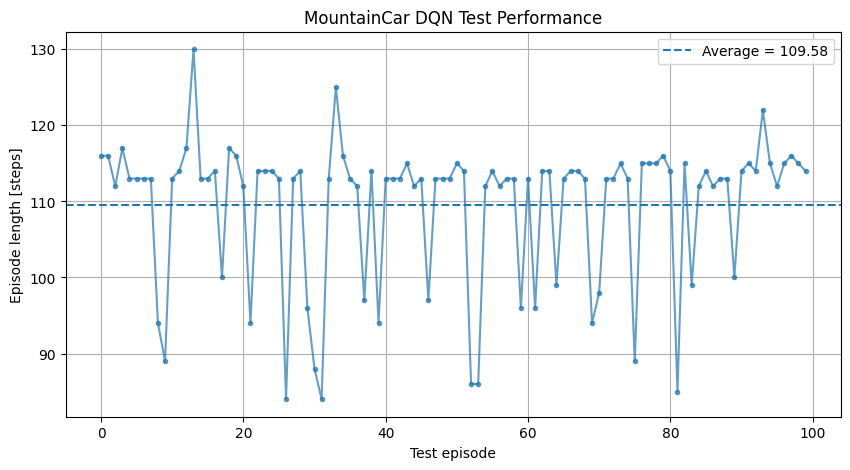

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    test_episode_lengths,
    marker="o",
    markersize=3,
    alpha=0.7
)

plt.axhline(
    average_length,
    linestyle="--",
    label=f"Average = {average_length:.2f}"
)

plt.xlabel("Test episode")
plt.ylabel("Episode length [steps]")

plt.title(
    "MountainCar DQN Test Performance"
)

plt.legend()
plt.grid()

plt.show()

In [38]:
state, info = env.reset()

terminated = False
truncated = False

trajectory = [
    state.copy()
]

actions = []

steps = 0


while not (
    terminated or truncated
):

    action = select_greedy_action(
        policy_net,
        state,
        device,
        preprocess_fn=preprocess_state
    )

    actions.append(action)

    (
        state,
        reward,
        terminated,
        truncated,
        info
    ) = env.step(action)

    trajectory.append(
        state.copy()
    )

    steps += 1


trajectory = np.array(
    trajectory
)

actions = np.array(
    actions
)


print(
    f"Trajectory completed "
    f"in {steps} steps."
)

Trajectory completed in 115 steps.


In [39]:
num_position_points = 300
num_velocity_points = 300


positions = np.linspace(
    env.observation_space.low[0],
    env.observation_space.high[0],
    num_position_points
)

velocities = np.linspace(
    env.observation_space.low[1],
    env.observation_space.high[1],
    num_velocity_points
)


position_grid, velocity_grid = np.meshgrid(
    positions,
    velocities
)

In [40]:
states = np.column_stack([
    position_grid.ravel(),
    velocity_grid.ravel()
])

In [41]:
normalized_states = normalize_state(
    states,
    state_low,
    state_high
)

In [42]:
states_tensor = torch.tensor(
    normalized_states,
    dtype=torch.float32,
    device=device
)

In [43]:
with torch.no_grad():

    q_values = policy_net(
        states_tensor
    )

    greedy_actions = torch.argmax(
        q_values,
        dim=1
    ).cpu().numpy()

In [44]:
policy = greedy_actions.reshape(
    velocity_grid.shape
)

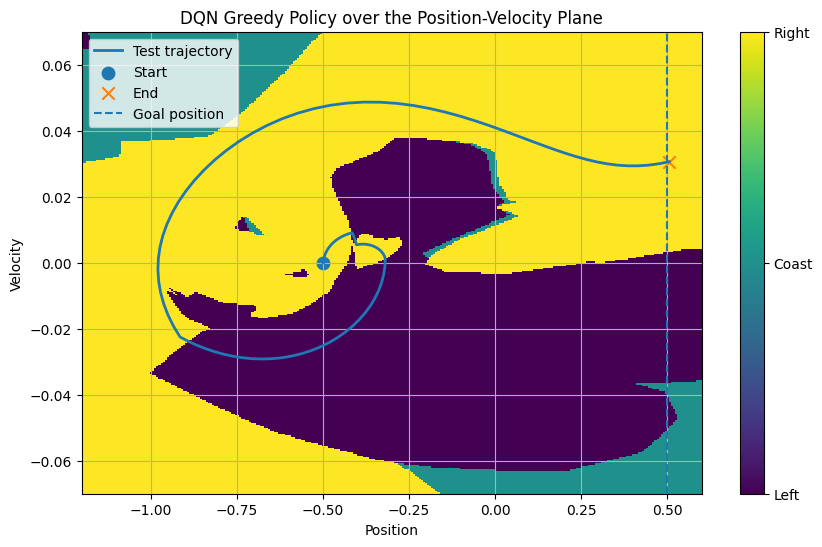

In [45]:
plt.figure(figsize=(10, 6))


im = plt.imshow(
    policy,
    origin="lower",
    aspect="auto",
    extent=[
        env.observation_space.low[0],
        env.observation_space.high[0],
        env.observation_space.low[1],
        env.observation_space.high[1]
    ],
    interpolation="nearest"
)


cbar = plt.colorbar(
    im,
    ticks=[0, 1, 2]
)

cbar.ax.set_yticklabels([
    "Left",
    "Coast",
    "Right"
])


plt.xlabel("Position")
plt.ylabel("Velocity")

plt.title(
    "DQN Greedy Policy over "
    "the Position-Velocity Plane"
)


plt.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    linewidth=2,
    label="Test trajectory"
)


plt.scatter(
    trajectory[0, 0],
    trajectory[0, 1],
    marker="o",
    s=80,
    label="Start"
)


plt.scatter(
    trajectory[-1, 0],
    trajectory[-1, 1],
    marker="x",
    s=80,
    label="End"
)


plt.axvline(
    x=0.5,
    linestyle="--",
    label="Goal position"
)


plt.legend()
plt.grid()

plt.show()

In [46]:
env.close()

render_env = gym.make(
    "MountainCar-v0",
    render_mode="human"
)


state, info = render_env.reset()

terminated = False
truncated = False

steps = 0


while not (
    terminated or truncated
):

    action = select_greedy_action(
        policy_net,
        state,
        device,
        preprocess_fn=preprocess_state
    )

    (
        state,
        reward,
        terminated,
        truncated,
        info
    ) = render_env.step(action)

    steps += 1


render_env.close()


print(
    f"Episode completed in "
    f"{steps} steps."
)

Episode completed in 116 steps.
